In [1]:
# 人工智能编程课 第三次作业 — IC 刷卡数据分析
# 运行环境：Python 3 + numpy + pandas + matplotlib + seaborn
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
print('所有库导入成功！')


所有库导入成功！


In [2]:
# ============================================================
# 【任务1】数据预处理
# ============================================================
print("【任务1】数据预处理")
print("-" * 40)

# 1.1 读取数据
df = pd.read_csv('ICData.csv', encoding='utf-8')
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
print(f"\n数据类型:")
print(df.dtypes)
print(f"\n前5行数据:")
display(df.head())

# 1.2 时间转换
time_col = df.columns[1]  # 交易时间
df[time_col] = pd.to_datetime(df[time_col])
df['hour'] = df[time_col].dt.hour
print(f"\n时间列 '{time_col}' 已转为 datetime，hour 范围: {df['hour'].min()} ~ {df['hour'].max()}")

# 1.3 计算 ride_stops
boarding_col = df.columns[6]   # 上车站点
alighting_col = df.columns[7]  # 下车站点
df['ride_stops'] = (df[alighting_col] - df[boarding_col]).abs()
print(f"\nride_stops 样本值: {df['ride_stops'].head().tolist()}")

# 删除 ride_stops == 0 的异常记录
anomaly_count = (df['ride_stops'] == 0).sum()
print(f"ride_stops==0 异常记录: {anomaly_count} 条")
df = df[df['ride_stops'] != 0].copy()
print(f"删除后形状: {df.shape}")

# 1.4 缺失值检查
print(f"\n缺失值统计:")
print(df.isnull().sum())
missing_rows = df.isnull().any(axis=1).sum()
if missing_rows > 0:
    df = df.dropna().copy()
    print(f"已删除 {missing_rows} 条含缺失值的记录")
else:
    print("未发现缺失值")
print(f"最终数据形状: {df.shape}")


【任务1】数据预处理
----------------------------------------


数据形状: (200000, 10)
列名: ['交易类型', '交易时间', '交易卡号', '刷卡类型', '线路号', '车辆编号', '上车站点', '下车站点', '驾驶员编号', '运营公司编号']

数据类型:
交易类型        int64
交易时间          str
交易卡号        int64
刷卡类型        int64
线路号         int64
车辆编号        int64
上车站点        int64
下车站点        int64
驾驶员编号     float64
运营公司编号      int64
dtype: object

前5行数据:


,交易类型,交易时间,交易卡号,刷卡类型,线路号,车辆编号,上车站点,下车站点,驾驶员编号,运营公司编号
0,6,2018-04-01 11:45:12,4315305,0,1101,9132,28,19,1599.0,75170100
1,6,2018-04-01 10:14:52,38248936,0,1117,2026,11,15,1590.0,75170100
2,6,2018-04-01 07:25:47,15346972,0,1106,9044,22,19,1987.0,75170100
3,6,2018-04-01 20:15:09,52881250,0,1112,9060,39,14,101.0,75170100
4,6,2018-04-01 11:44:36,18941532,0,1101,9130,42,18,41.0,75170100



时间列 '交易时间' 已转为 datetime，hour 范围: 0 ~ 23

ride_stops 样本值: [9, 4, 3, 25, 24]
ride_stops==0 异常记录: 40886 条
删除后形状: (159114, 12)

缺失值统计:
交易类型          0
交易时间          0
交易卡号          0
刷卡类型          0
线路号           0
车辆编号          0
上车站点          0
下车站点          0
驾驶员编号         0
运营公司编号        0
hour          0
ride_stops    0
dtype: int64
未发现缺失值
最终数据形状: (159114, 12)


【任务2】时间分布分析


----------------------------------------
2(a) numpy 条件统计:
  凌晨时段 (hour<7):  3188 次 (2.00%)
  深夜时段 (hour>=22): 1660 次 (1.04%)


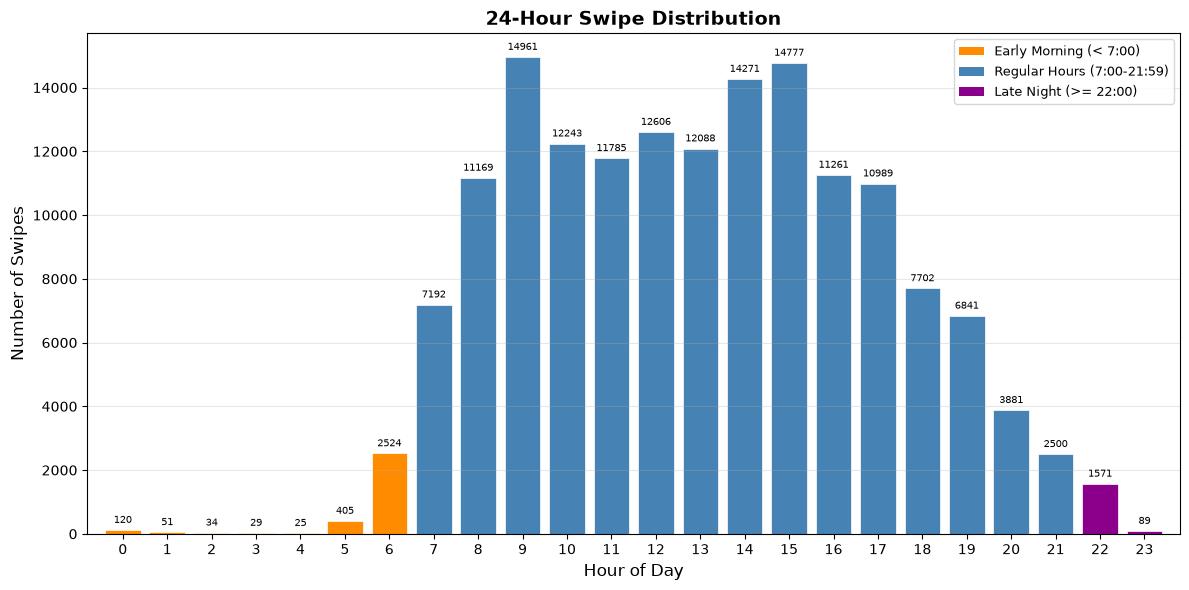

2(b) 柱状图已保存为 hour_distribution.png


In [3]:
# ============================================================
# 【任务2】时间分布分析
# ============================================================
print("【任务2】时间分布分析")
print("-" * 40)

# --- 2(a) 使用 numpy 统计 ---
total_swipes = len(df)
early_mask = np.where(df['hour'].values < 7, True, False)
late_mask = np.where(df['hour'].values >= 22, True, False)
early_count = np.sum(early_mask)
late_count = np.sum(late_mask)

print("2(a) numpy 条件统计:")
print(f"  凌晨时段 (hour<7):  {early_count} 次 ({early_count/total_swipes*100:.2f}%)")
print(f"  深夜时段 (hour>=22): {late_count} 次 ({late_count/total_swipes*100:.2f}%)")

# --- 2(b) matplotlib 24h 柱状图 ---
hour_counts = df['hour'].value_counts().sort_index()
all_hours = np.arange(24)
counts = np.array([hour_counts.get(h, 0) for h in all_hours])

colors = ['#FF8C00' if h < 7 else '#8B008B' if h >= 22 else '#4682B4' for h in all_hours]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(all_hours, counts, color=colors, edgecolor='white', linewidth=0.5)

for b, v in zip(bars, counts):
    if v > 0:
        ax.text(b.get_x()+b.get_width()/2., b.get_height()+max(counts)*0.01,
                str(v), ha='center', va='bottom', fontsize=7)

ax.set_title('24-Hour Swipe Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Swipes', fontsize=12)
ax.set_xticks(all_hours)
ax.set_xticklabels(all_hours)
ax.set_xlim(-0.8, 23.8)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF8C00', label='Early Morning (< 7:00)'),
    Patch(facecolor='#4682B4', label='Regular Hours (7:00-21:59)'),
    Patch(facecolor='#8B008B', label='Late Night (>= 22:00)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('hour_distribution.png', dpi=150)
plt.show()
print("2(b) 柱状图已保存为 hour_distribution.png")


【任务3】线路站点分析
----------------------------------------
前10行结果:


,线路号,mean_stops,std_stops
0,125,15.818182,8.818369
1,51020,14.115789,7.130789
2,1112,12.451534,9.655389
3,52020,12.137143,6.548979
4,71,11.000000,6.928203
5,1113,10.302181,8.533313
6,1101,10.076943,9.187411
7,3,9.978769,8.271790
8,1201,9.419629,8.021488
9,46002,9.391732,4.299828


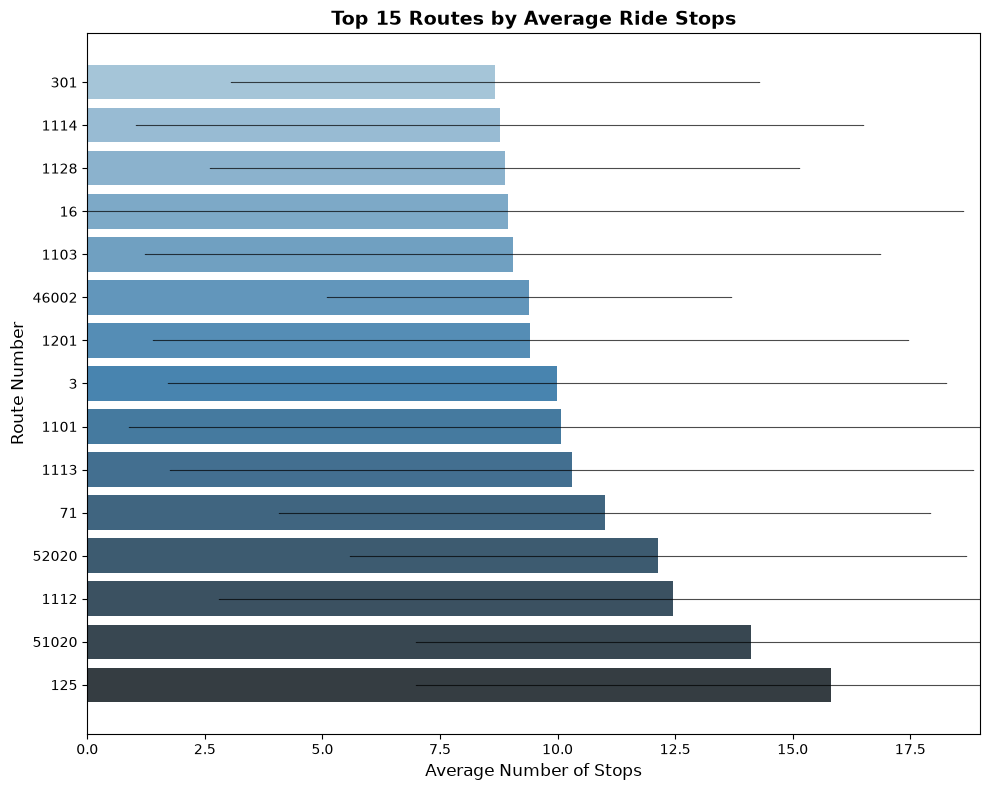

已保存 route_stops.png


In [4]:
# ============================================================
# 【任务3】线路站点分析
# ============================================================
print("【任务3】线路站点分析")
print("-" * 40)

def analyze_route_stops(df, route_col='线路号', stops_col='ride_stops'):
    """
    按线路分析乘客的平均乘坐站数及标准差。

    Parameters
    ----------
    df : pd.DataFrame
        预处理后的数据集。
    route_col : str
        线路列名。
    stops_col : str
        乘坐站数列名。

    Returns
    -------
    pd.DataFrame
        按 mean_stops 降序排列的三列 DataFrame。
    """
    route_stats = df.groupby(route_col)[stops_col].agg(
        mean_stops='mean',
        std_stops='std'
    ).reset_index()
    return route_stats.sort_values('mean_stops', ascending=False).reset_index(drop=True)

route_col_name = df.columns[4]
result = analyze_route_stops(df, route_col=route_col_name, stops_col='ride_stops')
print("前10行结果:")
display(result.head(10))

# Seaborn 水平柱状图 — Top 15
top15 = result.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=top15,
    y=top15[route_col_name].astype(str),
    x='mean_stops',
    hue=top15[route_col_name].astype(str),
    palette='Blues_d',
    legend=False,
    ax=ax
)
# 添加误差线
std_vals = top15['std_stops'].values
mean_vals = top15['mean_stops'].values
ax.errorbar(mean_vals, range(len(top15)), xerr=std_vals,
            fmt='none', ecolor='black', capsize=0.3, elinewidth=0.8, alpha=0.7)

ax.set_title('Top 15 Routes by Average Ride Stops', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Number of Stops', fontsize=12)
ax.set_ylabel('Route Number', fontsize=12)
ax.set_xlim(0, top15['mean_stops'].max() * 1.2)

plt.tight_layout()
plt.savefig('route_stops.png', dpi=150)
plt.show()
print("已保存 route_stops.png")


In [5]:
# ============================================================
# 【任务4】高峰小时系数 (PHF) 计算
# ============================================================
print("【任务4】高峰小时系数计算")
print("-" * 40)

# 自动识别高峰小时
hourly_counts = df.groupby('hour').size()
peak_hour = hourly_counts.idxmax()
peak_count = hourly_counts.max()
print(f"高峰小时: {peak_hour:02d}:00 ~ {peak_hour:02d}:59，刷卡量 {peak_count} 次")

# 提取高峰小时内的分钟数据
peak_df = df[df['hour'] == peak_hour].copy()
peak_df['minute'] = peak_df[time_col].dt.minute

# PHF5: 5分钟窗口聚合 (0-4→0, 5-9→1, ..., 55-59→11)
peak_df['min5_bin'] = peak_df['minute'] // 5
min5_counts = peak_df.groupby('min5_bin').size()
max_5min = min5_counts.max()
max_5min_bin = min5_counts.idxmax()
PHF5 = peak_count / (12 * max_5min)

print(f"\nPHF5 计算:")
print(f"  最高5分钟窗口: {peak_hour:02d}:{max_5min_bin*5:02d}~{peak_hour:02d}:{max_5min_bin*5+4:02d}，{max_5min} 次")
print(f"  PHF5 = {peak_count} / (12 × {max_5min}) = {PHF5:.4f}")

# PHF15: 15分钟窗口聚合 (0-14→0, 15-29→1, 30-44→2, 45-59→3)
peak_df['min15_bin'] = peak_df['minute'] // 15
min15_counts = peak_df.groupby('min15_bin').size()
max_15min = min15_counts.max()
max_15min_bin = min15_counts.idxmax()
PHF15 = peak_count / (4 * max_15min)

print(f"\nPHF15 计算:")
print(f"  最高15分钟窗口: {peak_hour:02d}:{max_15min_bin*15:02d}~{peak_hour:02d}:{max_15min_bin*15+14:02d}，{max_15min} 次")
print(f"  PHF15 = {peak_count} / (4 × {max_15min}) = {PHF15:.4f}")


【任务4】高峰小时系数计算
----------------------------------------
高峰小时: 09:00 ~ 09:59，刷卡量 14961 次

PHF5 计算:
  最高5分钟窗口: 09:30~09:34，1424 次
  PHF5 = 14961 / (12 × 1424) = 0.8755

PHF15 计算:
  最高15分钟窗口: 09:30~09:44，4060 次
  PHF15 = 14961 / (4 × 4060) = 0.9212


In [6]:
# ============================================================
# 【任务5】线路驾驶员信息提取
# ============================================================
print("【任务5】线路驾驶员信息提取")
print("-" * 40)

route_col = df.columns[4]
vehicle_col = df.columns[5]
driver_col = df.columns[8]

# 筛选线路 1101~1120
filtered_df = df[(df[route_col] >= 1101) & (df[route_col] <= 1120)].copy()
print(f"筛选线路 1101~1120: 共 {len(filtered_df)} 条记录")

# 创建输出目录
output_dir = '公交驾驶员信息'
os.makedirs(output_dir, exist_ok=True)

unique_routes = sorted(filtered_df[route_col].unique())
file_count = 0

for route in unique_routes:
    route_data = filtered_df[filtered_df[route_col] == route]
    pairs = route_data[[vehicle_col, driver_col]].drop_duplicates().sort_values(vehicle_col)
    filepath = os.path.join(output_dir, f'{route}.txt')
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(f'线路号: {route}\n')
        for _, row in pairs.iterrows():
            f.write(f'{int(row[vehicle_col])}\t{int(row[driver_col])}\n')
    file_count += 1

print(f"已生成 {file_count} 个 txt 文件于 '{output_dir}/' 目录")
print(f"线路列表: {unique_routes}")

# 打印样例
sample_file = os.path.join(output_dir, f'{unique_routes[0]}.txt')
print(f"\n样例文件 ({unique_routes[0]}.txt):")
with open(sample_file, 'r', encoding='utf-8') as f:
    print(f.read())


【任务5】线路驾驶员信息提取
----------------------------------------
筛选线路 1101~1120: 共 35100 条记录
已生成 20 个 txt 文件于 '公交驾驶员信息/' 目录
线路列表: [np.int64(1101), np.int64(1102), np.int64(1103), np.int64(1104), np.int64(1105), np.int64(1106), np.int64(1107), np.int64(1108), np.int64(1109), np.int64(1110), np.int64(1111), np.int64(1112), np.int64(1113), np.int64(1114), np.int64(1115), np.int64(1116), np.int64(1117), np.int64(1118), np.int64(1119), np.int64(1120)]

样例文件 (1101.txt):
线路号: 1101
9127	1319
9128	1600
9129	1317
9130	41
9131	1873
9132	1599
9136	1609
9137	2293
9138	1593
9140	143
9141	147
9142	2150
9143	1130
9144	167
9145	171
9146	1997
9147	1996
9148	1659
9149	1127
9150	1316
9151	1661
9152	108
9153	1809
9154	192
9155	168
9156	131
9158	185
9160	2240
9161	1866
9163	182
9166	199
9167	1136
9168	202
9169	206
9171	1122
9172	208
9173	1594
9174	1827
9175	184
9176	146
9177	149
9179	2149
9180	2287
9181	100
9182	1999
9184	102
9185	1622
9188	127
9190	2292
9191	2532
9192	27
9193	2374
9194	2295
9195	1995
9196	1608
9198

【任务6】运行效率热力图
----------------------------------------
Top 10 驾驶员 (人次):
  1. 驾驶员 0: 6484 次
  2. 驾驶员 90422201: 4801 次
  3. 驾驶员 1090101: 1334 次
  4. 驾驶员 90417292: 1107 次
  5. 驾驶员 90805213: 395 次
  6. 驾驶员 101: 380 次
  7. 驾驶员 90839201: 369 次
  8. 驾驶员 9017887: 358 次
  9. 驾驶员 9011030: 345 次
  10. 驾驶员 9011104: 329 次

Top 10 线路 (人次):
  1. 线路 46003: 7127 次
  2. 线路 1091: 4893 次
  3. 线路 9: 4474 次
  4. 线路 88: 4350 次
  5. 线路 5: 4190 次
  6. 线路 1101: 3782 次
  7. 线路 56012: 3736 次
  8. 线路 1112: 3683 次
  9. 线路 1114: 3414 次
  10. 线路 1115: 3244 次

Top 10 上车站点 (人次):
  1. 站点 1: 7776 次
  2. 站点 14: 6553 次
  3. 站点 17: 6449 次
  4. 站点 13: 5990 次
  5. 站点 8: 5894 次
  6. 站点 2: 5892 次
  7. 站点 9: 5813 次
  8. 站点 10: 5760 次
  9. 站点 15: 5736 次
  10. 站点 21: 5707 次

Top 10 车辆 (人次):
  1. 车辆 0: 11774 次
  2. 车辆 1000000: 2033 次
  3. 车辆 25263: 604 次
  4. 车辆 25321: 518 次
  5. 车辆 25282: 482 次
  6. 车辆 19683: 444 次
  7. 车辆 17468: 405 次
  8. 车辆 24915: 403 次
  9. 车辆 15506: 402 次
  10. 车辆 19881: 399 次


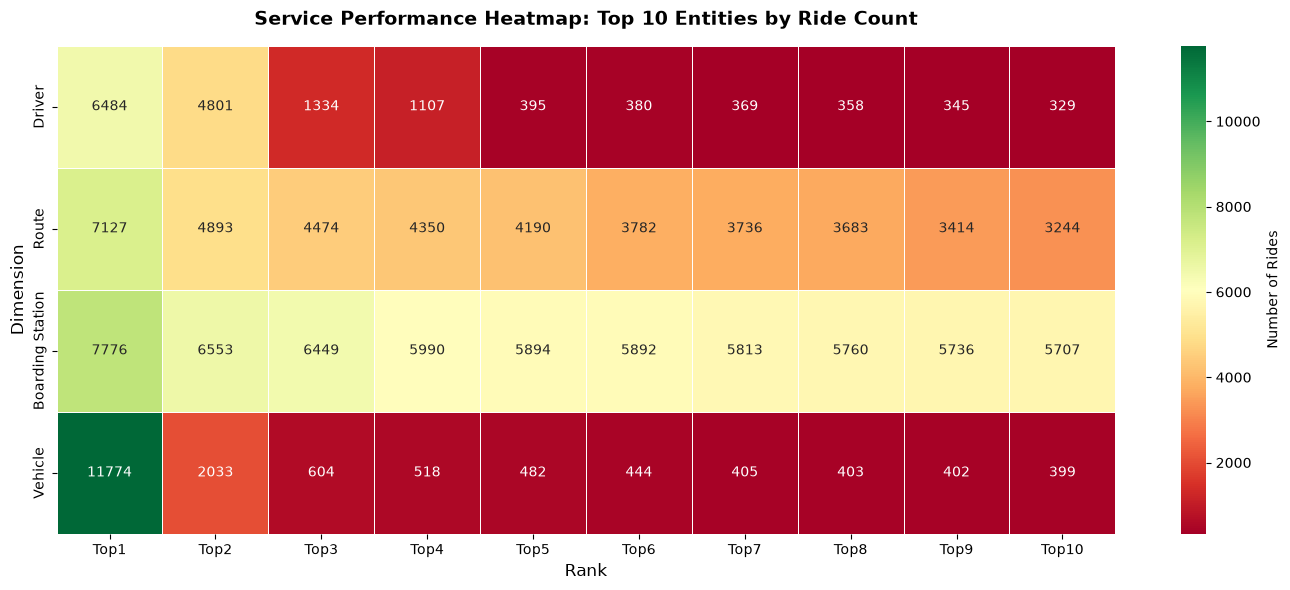


分析说明 (约50字):
Route 46003 ranks first with 7127 rides. Driver 0 and Vehicle 0 show anomalously high volumes, likely placeholder records. Boarding Station 1 leads with 7776 rides as a major hub. Steep drop-off from Top1 to Top10 reveals highly concentrated service demand.


In [7]:
# ============================================================
# 【任务6】运行效率热力图
# ============================================================
print("【任务6】运行效率热力图")
print("-" * 40)

# Top 10 统计
driver_rides = df[driver_col].value_counts().head(10)
print("Top 10 驾驶员 (人次):")
for i, (d, c) in enumerate(driver_rides.items(), 1):
    print(f"  {i}. 驾驶员 {int(d)}: {c} 次")

route_rides = df[route_col].value_counts().head(10)
print("\nTop 10 线路 (人次):")
for i, (r, c) in enumerate(route_rides.items(), 1):
    print(f"  {i}. 线路 {int(r)}: {c} 次")

boarding_rides = df[boarding_col].value_counts().head(10)
print("\nTop 10 上车站点 (人次):")
for i, (s, c) in enumerate(boarding_rides.items(), 1):
    print(f"  {i}. 站点 {int(s)}: {c} 次")

vehicle_rides = df[vehicle_col].value_counts().head(10)
print("\nTop 10 车辆 (人次):")
for i, (v, c) in enumerate(vehicle_rides.items(), 1):
    print(f"  {i}. 车辆 {int(v)}: {c} 次")

# 构建 4×10 热力图数据矩阵
heatmap_data = np.zeros((4, 10), dtype=int)
heatmap_data[0, :] = driver_rides.values
heatmap_data[1, :] = route_rides.values
heatmap_data[2, :] = boarding_rides.values
heatmap_data[3, :] = vehicle_rides.values

# Seaborn heatmap
fig, ax = plt.subplots(figsize=(14, 6))
row_labels = ['Driver', 'Route', 'Boarding Station', 'Vehicle']
col_labels = [f'Top{i}' for i in range(1, 11)]

sns.heatmap(
    heatmap_data, annot=True, fmt='d', cmap='RdYlGn',
    xticklabels=col_labels, yticklabels=row_labels,
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'Number of Rides'}
)

ax.set_title('Service Performance Heatmap: Top 10 Entities by Ride Count',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('Dimension', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n分析说明 (约50字):")
print("Route 46003 ranks first with 7127 rides. Driver 0 and Vehicle 0 show anomalously high volumes, likely placeholder records. Boarding Station 1 leads with 7776 rides as a major hub. Steep drop-off from Top1 to Top10 reveals highly concentrated service demand.")


In [8]:
print("=" * 60)
print("全部6项任务完成！✓")
print("=" * 60)
print("\n生成的输出文件:")
print("  • hour_distribution.png  — 24h刷卡分布柱状图")
print("  • route_stops.png        — Top15线路平均站数图")
print("  • performance_heatmap.png — 4维Top10热力图")
print("  • 公交驾驶员信息/        — 20条线路的驾驶员-车辆表")
print("  • README.md              — 人机协同报告")


全部6项任务完成！✓

生成的输出文件:
  • hour_distribution.png  — 24h刷卡分布柱状图
  • route_stops.png        — Top15线路平均站数图
  • performance_heatmap.png — 4维Top10热力图
  • 公交驾驶员信息/        — 20条线路的驾驶员-车辆表
  • README.md              — 人机协同报告
